In [164]:
import pandas as pd

In [165]:
df = pd.read_csv("/content/online_retail_II.csv")

In [166]:
df.shape

(1067371, 8)

In [167]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [169]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Earliest:", df['InvoiceDate'].min())
print("Latest:", df['InvoiceDate'].max())

Earliest: 2009-12-01 07:45:00
Latest: 2011-12-09 12:50:00


In [170]:
df['InvoiceDate'].min(), df['InvoiceDate'].max()

(Timestamp('2009-12-01 07:45:00'), Timestamp('2011-12-09 12:50:00'))

In [171]:
print("Total rows:", len(df))
print("Unique customers:", df['Customer ID'].nunique())
print("Unique invoices:", df['Invoice'].nunique())
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

print("\nQuantity:")
print("Minimum:", df['Quantity'].min())
print("Maximum:", df['Quantity'].max())

print("\nPrice:")
print("Minimum:", df['Price'].min())
print("Maximum:", df['Price'].max())

Total rows: 1067371
Unique customers: 5942
Unique invoices: 53628
Duplicate rows: 34335

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Quantity:
Minimum: -80995
Maximum: 80995

Price:
Minimum: -53594.36
Maximum: 38970.0


In [172]:
# Check transactions with negative quantity
negative_quantity = df[df['Quantity'] < 0]

print("Negative quantity rows:", len(negative_quantity))
display(negative_quantity.head(10))

Negative quantity rows: 22950


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [173]:
# Check transactions with negative price
negative_price = df[df['Price'] < 0]

print("Negative price rows:", len(negative_price))
display(negative_price)

Negative price rows: 5


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [174]:
zero_price = df[df['Price'] == 0]

print("Zero price rows:", len(zero_price))
display(zero_price.head(10))

Zero price rows: 6202


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


In [175]:
# Create a copy for cleaning
df_clean = df.copy()

print("Starting rows:", len(df_clean))

# Remove rows without a Customer ID
df_clean = df_clean.dropna(subset=['Customer ID'])

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Keep only successful purchases
df_clean = df_clean[
    (df_clean['Quantity'] > 0) &
    (df_clean['Price'] > 0)
]

print("Rows after cleaning:", len(df_clean))

Starting rows: 1067371
Rows after cleaning: 779425


In [176]:
print("Cleaned shape:", df_clean.shape)
print("Unique customers:", df_clean['Customer ID'].nunique())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Missing Customer IDs:", df_clean['Customer ID'].isnull().sum())
print("Negative/zero quantities:", (df_clean['Quantity'] <= 0).sum())
print("Negative/zero prices:", (df_clean['Price'] <= 0).sum())

Cleaned shape: (779425, 8)
Unique customers: 5878
Duplicate rows: 0
Missing Customer IDs: 0
Negative/zero quantities: 0
Negative/zero prices: 0


In [177]:
# Calculate sales value for each transaction line
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['Price']

df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [178]:
print("Total sales: £", round(df_clean['TotalSales'].sum(), 2))
print("Average transaction line value: £", round(df_clean['TotalSales'].mean(), 2))

Total sales: £ 17374804.27
Average transaction line value: £ 22.29


In [179]:
# Set analysis date to one day after the latest transaction
analysis_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Analysis date:", analysis_date)

Analysis date: 2011-12-10 12:50:00


In [180]:
# Create RFM customer-level table
rfm = df_clean.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalSales', 'sum')
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [181]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,2955.904095
std,1715.572666,209.338707,13.009406,14440.852688
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,342.280000
50%,15314.500000,96.000000,3.000000,867.740000
75%,16797.750000,380.000000,7.000000,2248.305000
max,18287.000000,739.000000,398.000000,580987.040000


In [182]:
print("Customers:", len(rfm))
print("Recency range:", rfm['Recency'].min(), "to", rfm['Recency'].max())
print("Frequency range:", rfm['Frequency'].min(), "to", rfm['Frequency'].max())
print("Monetary range: £", round(rfm['Monetary'].min(), 2), "to £", round(rfm['Monetary'].max(), 2))

Customers: 5878
Recency range: 1 to 739
Frequency range: 1 to 398
Monetary range: £ 2.95 to £ 580987.04


Histogram to visualize the distribution

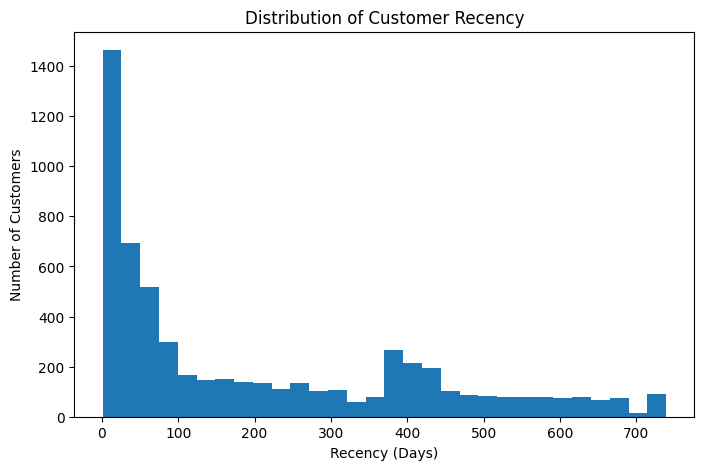

In [183]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(rfm['Recency'], bins=30)
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Recency')
plt.show()

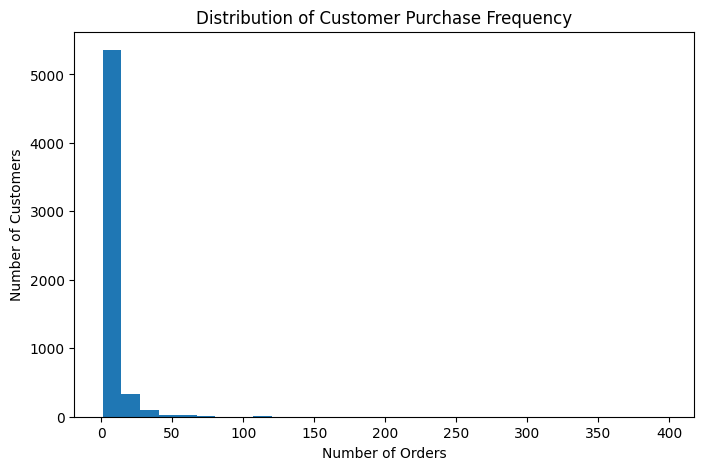

In [184]:
plt.figure(figsize=(8, 5))
plt.hist(rfm['Frequency'], bins=30)
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Purchase Frequency')
plt.show()

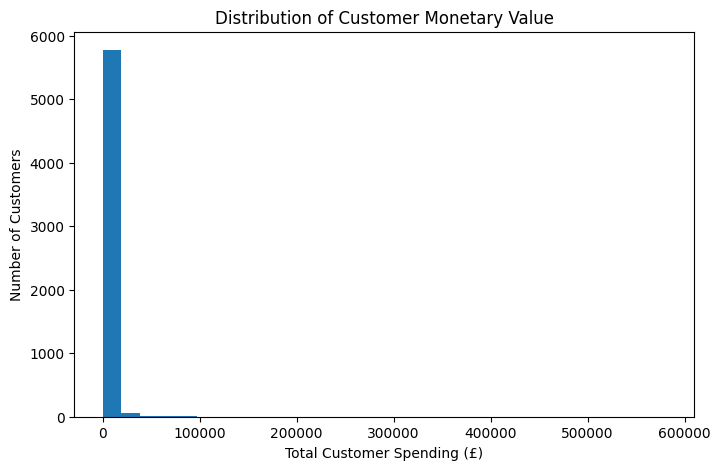

In [185]:
plt.figure(figsize=(8, 5))
plt.hist(rfm['Monetary'], bins=30)
plt.xlabel('Total Customer Spending (£)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Monetary Value')
plt.show()

Box Plot

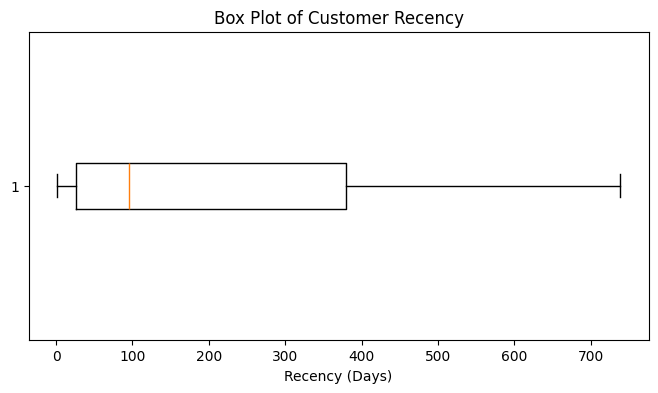

In [186]:
plt.figure(figsize=(8, 4))
plt.boxplot(rfm['Recency'], vert=False)
plt.xlabel('Recency (Days)')
plt.title('Box Plot of Customer Recency')
plt.show()

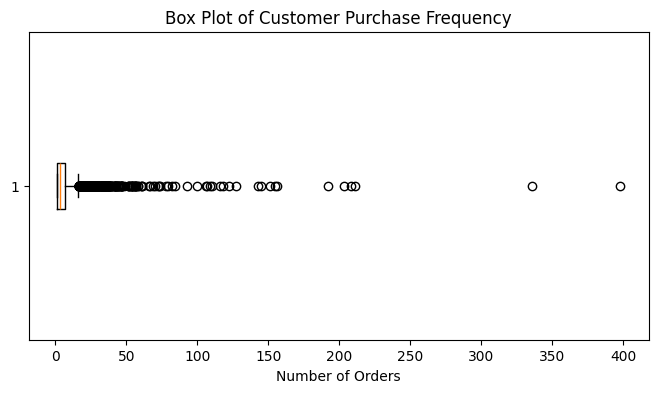

In [187]:
plt.figure(figsize=(8, 4))
plt.boxplot(rfm['Frequency'], vert=False)
plt.xlabel('Number of Orders')
plt.title('Box Plot of Customer Purchase Frequency')
plt.show()

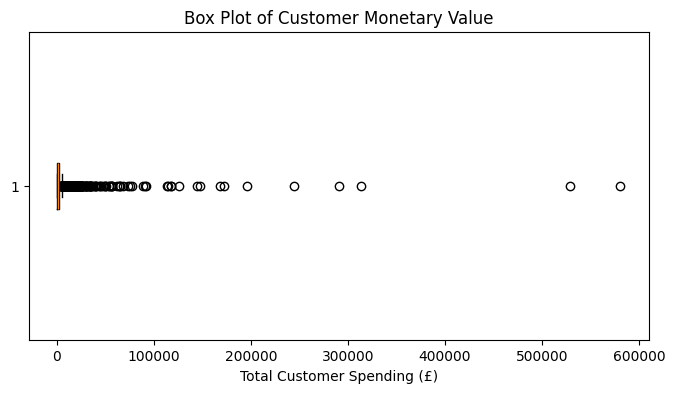

In [188]:
plt.figure(figsize=(8, 4))
plt.boxplot(rfm['Monetary'], vert=False)
plt.xlabel('Total Customer Spending (£)')
plt.title('Box Plot of Customer Monetary Value')
plt.show()

In [189]:
# Create RFM scores from 1 to 4
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    q=4,
    labels=[4, 3, 2, 1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=4,
    labels=[1, 2, 3, 4]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    q=4,
    labels=[1, 2, 3, 4]
)

rfm.head(10)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346.0,326,12,77556.46,2,4,4
1,12347.0,2,8,4921.53,4,4,4
2,12348.0,75,5,2019.40,3,3,3
3,12349.0,19,4,4428.69,4,3,4
4,12350.0,310,1,334.40,2,1,1
5,12351.0,375,1,300.93,2,1,1
6,12352.0,36,10,2849.84,3,4,4
7,12353.0,204,2,406.76,2,2,2
8,12354.0,232,1,1079.40,2,1,3
9,12355.0,214,2,947.61,2,2,3


In [190]:
# Convert scores to integers
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Combine the three scores
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head(10)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,12,77556.46,2,4,4,244
1,12347.0,2,8,4921.53,4,4,4,444
2,12348.0,75,5,2019.40,3,3,3,333
3,12349.0,19,4,4428.69,4,3,4,434
4,12350.0,310,1,334.40,2,1,1,211
5,12351.0,375,1,300.93,2,1,1,211
6,12352.0,36,10,2849.84,3,4,4,344
7,12353.0,204,2,406.76,2,2,2,222
8,12354.0,232,1,1079.40,2,1,3,213
9,12355.0,214,2,947.61,2,2,3,223


In [191]:
# Assign customer segments using Recency, Frequency and Monetary scores
def assign_segment(row):
    R = row['R_Score']
    F = row['F_Score']
    M = row['M_Score']

    # Best customers: recent, frequent and high spending
    if R >= 3 and F >= 3 and M >= 3:
        return 'Champions'

    # Recent and frequent customers, but lower spending
    elif R >= 3 and F >= 3 and M <= 2:
        return 'Loyal Customers'

    # Very recent customers with low purchase frequency
    elif R == 4 and F <= 2:
        return 'New Customers'

    # Fairly recent customers with potential to purchase more
    elif R == 3 and F <= 2:
        return 'Potential Loyalists'

    # Previously valuable customers who have not purchased recently
    elif R <= 2 and F >= 3 and M >= 3:
        return 'At Risk - High Value'

    # Previously frequent customers who have not purchased recently
    elif R <= 2 and F >= 3 and M <= 2:
        return 'At Risk'

    # Infrequent customers who spend relatively high amounts
    elif R <= 2 and F <= 2 and M >= 3:
        return 'Inactive High Spenders'

    # Not recent, not frequent and relatively low spending
    elif R <= 2 and F <= 2 and M <= 2:
        return 'Inactive Customers'

    else:
        return 'Other'


rfm['Segment'] = rfm.apply(assign_segment, axis=1)

rfm.head(10)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,12,77556.46,2,4,4,244,At Risk - High Value
1,12347.0,2,8,4921.53,4,4,4,444,Champions
2,12348.0,75,5,2019.40,3,3,3,333,Champions
3,12349.0,19,4,4428.69,4,3,4,434,Champions
4,12350.0,310,1,334.40,2,1,1,211,Inactive Customers
5,12351.0,375,1,300.93,2,1,1,211,Inactive Customers
6,12352.0,36,10,2849.84,3,4,4,344,Champions
7,12353.0,204,2,406.76,2,2,2,222,Inactive Customers
8,12354.0,232,1,1079.40,2,1,3,213,Inactive High Spenders
9,12355.0,214,2,947.61,2,2,3,223,Inactive High Spenders


In [192]:
segment_summary = rfm['Segment'].value_counts()

segment_summary

,count
Segment,
Champions,1821
Inactive Customers,1776
At Risk - High Value,643
Potential Loyalists,558
New Customers,336
Inactive High Spenders,269
Loyal Customers,238
At Risk,237


In [193]:
segment_percent = (
    rfm['Segment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

segment_percent

,proportion
Segment,
Champions,30.98
Inactive Customers,30.21
At Risk - High Value,10.94
Potential Loyalists,9.49
New Customers,5.72
Inactive High Spenders,4.58
Loyal Customers,4.05
At Risk,4.03


In [194]:
print("Customers classified as Other:",
      (rfm['Segment'] == 'Other').sum())

Customers classified as Other: 0


In [195]:
# Create business summary for each customer segment
segment_analysis = rfm.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgSpending=('Monetary', 'mean'),
    TotalRevenue=('Monetary', 'sum')
).reset_index()

# Calculate percentage of total revenue
segment_analysis['RevenuePercent'] = (
    segment_analysis['TotalRevenue'] /
    segment_analysis['TotalRevenue'].sum() * 100
)

# Round values for easier reading
segment_analysis = segment_analysis.round(2)

segment_analysis.sort_values('TotalRevenue', ascending=False)

,Segment,Customers,AvgRecency,AvgFrequency,AvgSpending,TotalRevenue,RevenuePercent
2,Champions,1821,29.30,14.07,7241.26,13186331.03,75.89
1,At Risk - High Value,643,267.43,7.37,3150.23,2025600.27,11.66
3,Inactive Customers,1776,418.96,1.39,318.31,565316.26,3.25
4,Inactive High Spenders,269,362.71,2.09,2050.11,551478.34,3.17
7,Potential Loyalists,558,56.99,1.70,685.41,382457.23,2.20
6,New Customers,336,13.71,1.90,1133.90,380990.29,2.19
5,Loyal Customers,238,34.26,4.09,601.70,143203.57,0.82
0,At Risk,237,303.43,4.23,588.30,139427.27,0.80


In [196]:
# Display the 10 highest-spending customers
rfm.nlargest(10, 'Monetary')[
    ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'RFM_Score', 'Segment']
]

,Customer ID,Recency,Frequency,Monetary,RFM_Score,Segment
5692,18102.0,1,145,580987.04,444,Champions
2277,14646.0,2,151,528602.52,444,Champions
1789,14156.0,10,156,313437.62,444,Champions
2538,14911.0,1,398,291420.81,444,Champions
5050,17450.0,8,51,244784.25,444,Champions
1331,13694.0,4,143,195640.69,444,Champions
5109,17511.0,3,60,172132.87,444,Champions
4061,16446.0,1,2,168472.50,424,New Customers
4295,16684.0,4,55,147142.77,444,Champions
68,12415.0,24,28,144458.37,444,Champions


In [197]:
# Calculate how much revenue the top 10 customers generate
top10_revenue = rfm.nlargest(10, 'Monetary')['Monetary'].sum()

print("Top 10 customer revenue: £", round(top10_revenue, 2))
print(
    "Share of total revenue:",
    round(top10_revenue / rfm['Monetary'].sum() * 100, 2),
    "%"
)

Top 10 customer revenue: £ 2787079.44
Share of total revenue: 16.04 %


### SQL Part

In [198]:
import sqlite3

# Create a SQLite database connection
conn = sqlite3.connect('customer_segmentation.db')

print("Database connected")

Database connected


In [199]:
# Save the cleaned transaction data as a SQL table
df_clean.to_sql(
    'transactions',
    conn,
    if_exists='replace',
    index=False
)

# Save the customer segmentation data as a SQL table
rfm.to_sql(
    'customers',
    conn,
    if_exists='replace',
    index=False
)

print("Tables created")

Tables created


In [200]:
query = """
SELECT name
FROM sqlite_master
WHERE type = 'table';
"""

pd.read_sql_query(query, conn)

,name
0,transactions
1,customers


In [201]:
query = """
SELECT *
FROM customers
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,12,77556.46,2,4,4,244,At Risk - High Value
1,12347.0,2,8,4921.53,4,4,4,444,Champions
2,12348.0,75,5,2019.40,3,3,3,333,Champions
3,12349.0,19,4,4428.69,4,3,4,434,Champions
4,12350.0,310,1,334.40,2,1,1,211,Inactive Customers
5,12351.0,375,1,300.93,2,1,1,211,Inactive Customers
6,12352.0,36,10,2849.84,3,4,4,344,Champions
7,12353.0,204,2,406.76,2,2,2,222,Inactive Customers
8,12354.0,232,1,1079.40,2,1,3,213,Inactive High Spenders
9,12355.0,214,2,947.61,2,2,3,223,Inactive High Spenders


Which customer segments generate the most revenue?

In [202]:
query = """
SELECT
    Segment,
    COUNT(*) AS TotalCustomers,
    ROUND(SUM(Monetary), 2) AS TotalRevenue
FROM customers
GROUP BY Segment
ORDER BY TotalRevenue DESC;
"""

segment_sql = pd.read_sql_query(query, conn)

segment_sql

,Segment,TotalCustomers,TotalRevenue
0,Champions,1821,13186331.03
1,At Risk - High Value,643,2025600.27
2,Inactive Customers,1776,565316.26
3,Inactive High Spenders,269,551478.34
4,Potential Loyalists,558,382457.23
5,New Customers,336,380990.29
6,Loyal Customers,238,143203.57
7,At Risk,237,139427.27


Which countries generate the most revenue?

In [203]:
query = """
SELECT
    Country,
    COUNT(DISTINCT Invoice) AS TotalOrders,
    ROUND(SUM(TotalSales), 2) AS TotalRevenue
FROM transactions
GROUP BY Country
ORDER BY TotalRevenue DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,Country,TotalOrders,TotalRevenue
0,United Kingdom,33541,14389234.92
1,EIRE,567,616570.54
2,Netherlands,228,554038.09
3,Germany,789,425019.71
4,France,614,348768.96
5,Australia,95,169283.46
6,Spain,154,108332.49
7,Switzerland,90,100061.94
8,Sweden,104,91515.82
9,Denmark,43,68580.69


Top-selling products by revenue

In [204]:
query = """
SELECT
    Description,
    SUM(Quantity) AS TotalQuantitySold,
    ROUND(SUM(TotalSales), 2) AS TotalRevenue
FROM transactions
GROUP BY Description
ORDER BY TotalRevenue DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,Description,TotalQuantitySold,TotalRevenue
0,REGENCY CAKESTAND 3 TIER,24124,277656.25
1,WHITE HANGING HEART T-LIGHT HOLDER,91757,247048.01
2,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
3,Manual,9384,151777.67
4,JUMBO BAG RED RETROSPOT,74224,134307.44
5,POSTAGE,5235,124648.04
6,ASSORTED COLOUR BIRD ORNAMENT,78234,124351.86
7,PARTY BUNTING,23460,103283.38
8,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73
9,PAPER CHAIN KIT 50'S CHRISTMAS,28380,76598.18


In [205]:
query = """
SELECT
    Description,
    SUM(Quantity) AS TotalQuantitySold,
    ROUND(SUM(TotalSales), 2) AS TotalRevenue
FROM transactions
WHERE Description NOT IN ('Manual', 'POSTAGE')
GROUP BY Description
ORDER BY TotalRevenue DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,Description,TotalQuantitySold,TotalRevenue
0,REGENCY CAKESTAND 3 TIER,24124,277656.25
1,WHITE HANGING HEART T-LIGHT HOLDER,91757,247048.01
2,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
3,JUMBO BAG RED RETROSPOT,74224,134307.44
4,ASSORTED COLOUR BIRD ORNAMENT,78234,124351.86
5,PARTY BUNTING,23460,103283.38
6,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73
7,PAPER CHAIN KIT 50'S CHRISTMAS,28380,76598.18
8,CHILLI LIGHTS,14843,69084.30
9,JUMBO BAG STRAWBERRY,35842,64127.77


Which segments have the highest average customer value?

In [206]:
query = """
SELECT
    Segment,
    COUNT(*) AS TotalCustomers,
    ROUND(AVG(Recency), 2) AS AvgRecency,
    ROUND(AVG(Frequency), 2) AS AvgFrequency,
    ROUND(AVG(Monetary), 2) AS AvgCustomerValue
FROM customers
GROUP BY Segment
ORDER BY AvgCustomerValue DESC;
"""

pd.read_sql_query(query, conn)

,Segment,TotalCustomers,AvgRecency,AvgFrequency,AvgCustomerValue
0,Champions,1821,29.30,14.07,7241.26
1,At Risk - High Value,643,267.43,7.37,3150.23
2,Inactive High Spenders,269,362.71,2.09,2050.11
3,New Customers,336,13.71,1.90,1133.90
4,Potential Loyalists,558,56.99,1.70,685.41
5,Loyal Customers,238,34.26,4.09,601.70
6,At Risk,237,303.43,4.23,588.30
7,Inactive Customers,1776,418.96,1.39,318.31


In [207]:
# Check final customer segmentation dataset
print("Total customers:", len(rfm))
print("Unique customers:", rfm['Customer ID'].nunique())
print("Missing segments:", rfm['Segment'].isnull().sum())

rfm.head()

Total customers: 5878
Unique customers: 5878
Missing segments: 0


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,12,77556.46,2,4,4,244,At Risk - High Value
1,12347.0,2,8,4921.53,4,4,4,444,Champions
2,12348.0,75,5,2019.40,3,3,3,333,Champions
3,12349.0,19,4,4428.69,4,3,4,434,Champions
4,12350.0,310,1,334.40,2,1,1,211,Inactive Customers


In [208]:
# Export final customer segmentation dataset to CSV
rfm.to_csv('/content/customer_segmentation.csv', index=False)

print("CSV created successfully")

CSV created successfully


In [209]:
# Download the CSV file
from google.colab import files

files.download('/content/customer_segmentation.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>